# 植物叶片病害多分类（MobileNet）教学案例

**知识点概述**：植物叶片病害识别属于计算机视觉中的多分类任务，核心流程包括数据准备、图像预处理、卷积神经网络建模、训练与评估。MobileNet 是轻量级 CNN，适合在资源受限设备上进行快速推理。

**意义**：通过该案例可以理解深度学习在农业病害监测中的应用价值，并掌握一个完整的图像分类项目流程（从数据到模型部署前的评估）。

数据集：PlantVillage Dataset（已放置在 `D:\xiangmu\j4-yepian\data`）。

## 1. 环境与路径设置

下面先导入依赖、设置随机种子，并指定数据路径。注意数据结构应类似：

```
D:\xiangmu\j4-yepian\data\
  ├─ Tomato___Late_blight
  ├─ Tomato___healthy
  └─ ...
```

若解压后多了一层目录（如 `PlantVillage`），程序会自动识别。

In [1]:
import os
import random
from pathlib import Path

import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# 基本配置
DATA_DIR = Path(r"D:\xiangmu\j4-yepian\data")
BATCH_SIZE = 32
NUM_EPOCHS = 3
LR = 1e-3
SEED = 42

def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

use_cuda = torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")
if use_cuda:
    print("Device:", device, "-", torch.cuda.get_device_name(0))
else:
    print("Device:", device, "(CUDA not available)")

Device: cuda - NVIDIA GeForce RTX 3060 Laptop GPU


In [2]:
from pathlib import Path


def has_class_dirs(path: Path) -> bool:
    if not path.exists():
        return False
    for p in path.rglob("*"):
        if p.is_dir():
            subdirs = [d for d in p.iterdir() if d.is_dir()]
            if len(subdirs) > 5:
                return True
    return False


if has_class_dirs(DATA_DIR):
    print("Dataset found in:", DATA_DIR)
else:
    raise RuntimeError(
        "未检测到类别目录，请确认已将PlantVillage解压到 D:\\xiangmu\\j4-yepian\\data"
    )

Dataset found in: D:\xiangmu\j4-yepian\data


## 1.5 数据集位置确认

目前数据集已放在 `D:\xiangmu\j4-yepian\data`，这里仅做检测与提示，不再自动下载。

## 2. 读取数据并查看类别

这里用 `ImageFolder` 按“文件夹名=类别名”的方式读取数据，并输出类别数量与示例图像。

Dataset root: D:\xiangmu\j4-yepian\data\Plant_leave_diseases_dataset_with_augmentation
Num classes: 39
Classes (first 10): ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Background_without_leaves', 'Blueberry___healthy', 'Cherry___Powdery_mildew', 'Cherry___healthy', 'Corn___Cercospora_leaf_spot Gray_leaf_spot', 'Corn___Common_rust']


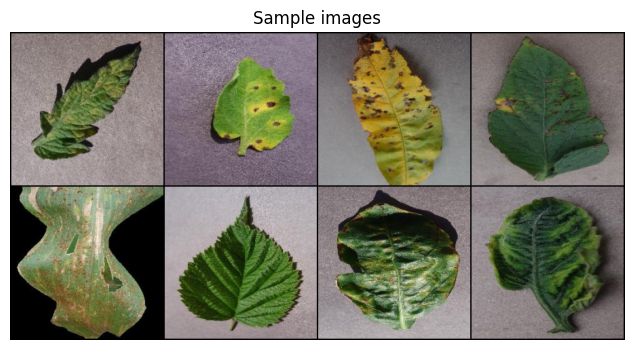

In [3]:
def find_dataset_root(data_dir: Path) -> Path:
    if not data_dir.exists():
        raise FileNotFoundError(f"Data dir not found: {data_dir}")

    # 递归搜索：找到包含多个子目录（类别）的最深层候选
    best_dir = None
    best_count = 0
    for p in [data_dir] + [d for d in data_dir.rglob("*") if d.is_dir()]:
        subdirs = [d for d in p.iterdir() if d.is_dir()]
        if len(subdirs) > best_count:
            # 进一步检查：子目录中是否包含图片
            has_image = False
            for d in subdirs[:3]:
                if any(f.suffix.lower() in {".jpg", ".jpeg", ".png"} for f in d.iterdir() if f.is_file()):
                    has_image = True
                    break
            if has_image and len(subdirs) > 1:
                best_dir = p
                best_count = len(subdirs)

    if best_dir is None:
        raise RuntimeError("未识别到类别目录，请检查数据结构。")
    return best_dir

dataset_root = find_dataset_root(DATA_DIR)
print("Dataset root:", dataset_root)

# 仅用于查看类别与示例图像
preview_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

full_dataset_preview = datasets.ImageFolder(dataset_root, transform=preview_transform)
class_names = full_dataset_preview.classes
print("Num classes:", len(class_names))
print("Classes (first 10):", class_names[:10])

# 可视化一个小批次
preview_loader = DataLoader(full_dataset_preview, batch_size=8, shuffle=True)
images, labels = next(iter(preview_loader))

grid = make_grid(images, nrow=4)
plt.figure(figsize=(8, 4))
plt.imshow(np.transpose(grid.numpy(), (1, 2, 0)))
plt.axis("off")
plt.title("Sample images")
plt.show()

## 3. 划分训练/验证/测试集并设置数据增强

我们将数据按 7:2:1 划分，同时为训练集添加适度的数据增强。

In [4]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

full_dataset = datasets.ImageFolder(dataset_root, transform=train_transform)

n_total = len(full_dataset)
n_train = int(n_total * 0.7)
n_val = int(n_total * 0.2)
n_test = n_total - n_train - n_val

train_set, val_set, test_set = random_split(
    full_dataset,
    lengths=[n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(SEED),
)

# 为验证/测试集替换为非增强的transform
val_set.dataset.transform = val_test_transform
test_set.dataset.transform = val_test_transform

print(f"Total: {n_total}, Train: {len(train_set)}, Val: {len(val_set)}, Test: {len(test_set)}")

Total: 61486, Train: 43040, Val: 12297, Test: 6149


## 4. DataLoader 与一个批次的形状

确认数据能够正确加载，输出一个批次的张量形状。

In [5]:
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

batch_images, batch_labels = next(iter(train_loader))
print("Batch images shape:", batch_images.shape)
print("Batch labels shape:", batch_labels.shape)

Batch images shape: torch.Size([32, 3, 224, 224])
Batch labels shape: torch.Size([32])


## 5. 构建 MobileNetV2 模型

使用预训练权重，加快收敛并提升精度。最后一层根据类别数进行替换。

In [6]:
num_classes = len(class_names)

try:
    weights = models.MobileNet_V2_Weights.DEFAULT
    model = models.mobilenet_v2(weights=weights)
    print("Loaded pretrained weights.")
except Exception as e:
    print("Pretrained weights download failed, using random init:", e)
    model = models.mobilenet_v2(weights=None)

model.classifier[1] = nn.Linear(model.last_channel, num_classes)
model = model.to(device)

print(model)

Loaded pretrained weights.
MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
        

## 6. 训练与验证

定义训练与评估函数，输出每个 epoch 的损失与准确率。

In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

NUM_EPOCHS = 20  # 自定义训练轮数，建议先设20-30轮
LR = 1e-3        # 学习率

def train_one_epoch(model, loader):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    return running_loss / total, correct / total


def evaluate(model, loader):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return running_loss / total, correct / total

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader)
    val_loss, val_acc = evaluate(model, val_loader)
    print(
        f"Epoch {epoch}/{NUM_EPOCHS} | "
        f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}"
    )

Epoch 1/20 | Train Loss: 0.2317, Train Acc: 0.9324 | Val Loss: 0.0767, Val Acc: 0.9739
Epoch 2/20 | Train Loss: 0.0949, Train Acc: 0.9699 | Val Loss: 0.0773, Val Acc: 0.9736
Epoch 3/20 | Train Loss: 0.0645, Train Acc: 0.9799 | Val Loss: 0.0389, Val Acc: 0.9876
Epoch 4/20 | Train Loss: 0.0592, Train Acc: 0.9813 | Val Loss: 0.0488, Val Acc: 0.9838
Epoch 5/20 | Train Loss: 0.0544, Train Acc: 0.9827 | Val Loss: 0.0498, Val Acc: 0.9853
Epoch 6/20 | Train Loss: 0.0504, Train Acc: 0.9844 | Val Loss: 0.0305, Val Acc: 0.9906
Epoch 7/20 | Train Loss: 0.0391, Train Acc: 0.9875 | Val Loss: 0.0646, Val Acc: 0.9803
Epoch 8/20 | Train Loss: 0.0391, Train Acc: 0.9872 | Val Loss: 0.0390, Val Acc: 0.9872
Epoch 9/20 | Train Loss: 0.0375, Train Acc: 0.9882 | Val Loss: 0.0477, Val Acc: 0.9882
Epoch 10/20 | Train Loss: 0.0331, Train Acc: 0.9897 | Val Loss: 0.0530, Val Acc: 0.9841
Epoch 11/20 | Train Loss: 0.0280, Train Acc: 0.9909 | Val Loss: 0.0287, Val Acc: 0.9914
Epoch 12/20 | Train Loss: 0.0310, Train A

## 7. 测试集评估与混淆矩阵

输出整体精度、分类报告，并绘制混淆矩阵。

Test Accuracy: 0.9928

Classification Report:
                                               precision    recall  f1-score   support

                           Apple___Apple_scab       1.00      1.00      1.00        96
                            Apple___Black_rot       1.00      1.00      1.00        87
                     Apple___Cedar_apple_rust       1.00      1.00      1.00       101
                              Apple___healthy       0.99      1.00      1.00       154
                    Background_without_leaves       0.99      0.98      0.99       105
                          Blueberry___healthy       1.00      1.00      1.00       159
                      Cherry___Powdery_mildew       1.00      0.99      1.00       112
                             Cherry___healthy       1.00      0.98      0.99       101
   Corn___Cercospora_leaf_spot Gray_leaf_spot       0.95      0.91      0.93       109
                           Corn___Common_rust       1.00      1.00      1.00       

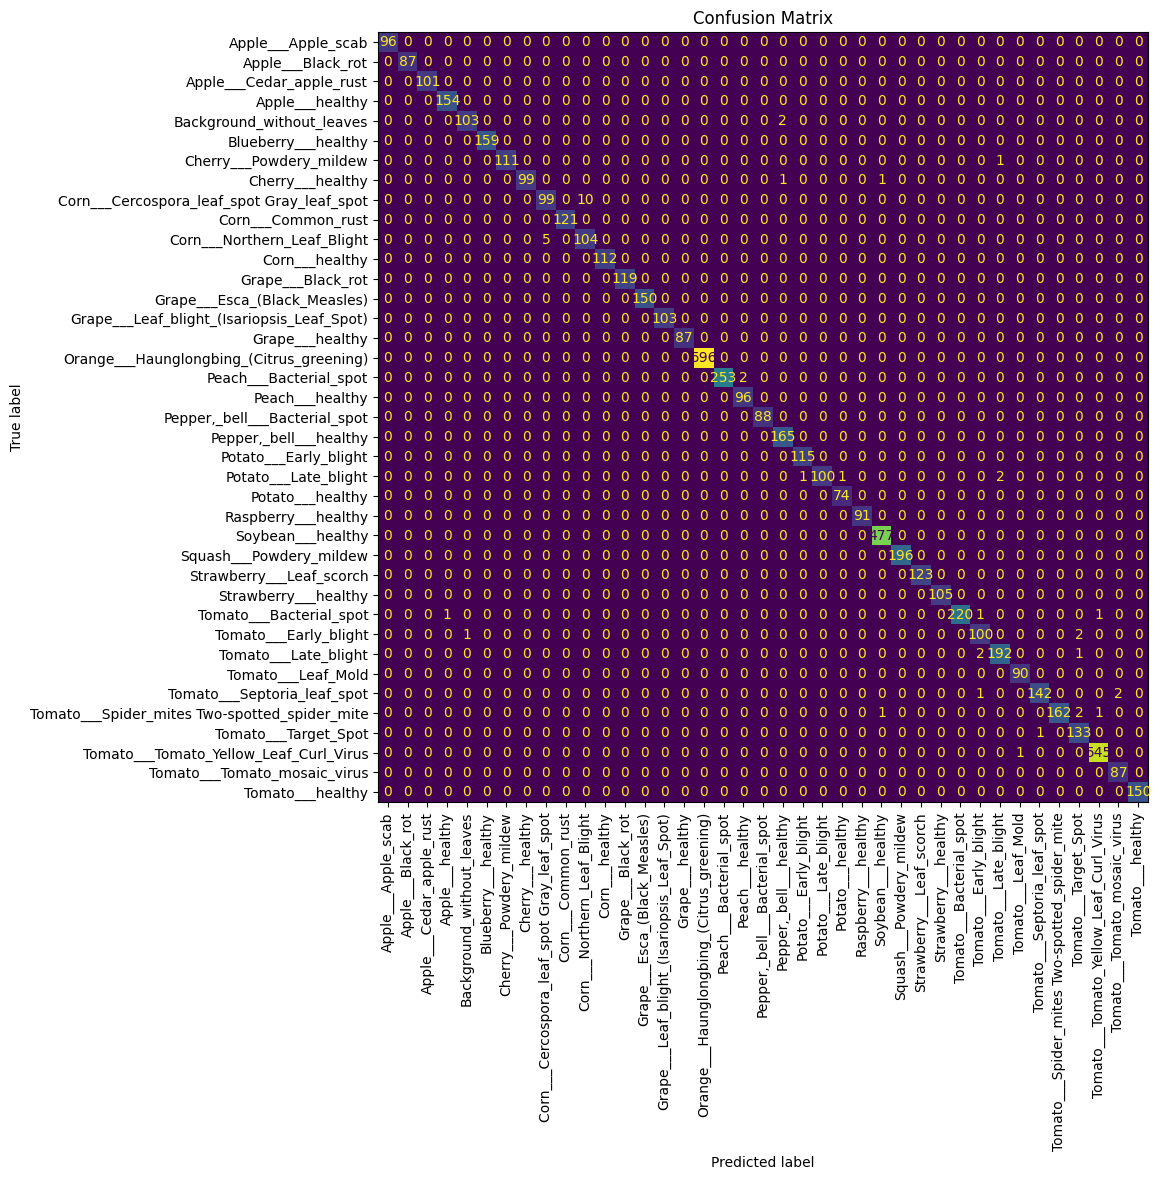

In [8]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

acc = (all_preds == all_labels).mean()
print("Test Accuracy:", f"{acc:.4f}")

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax, xticks_rotation=90, colorbar=False)
plt.title("Confusion Matrix")
plt.show()

## 8. 保存模型

保存训练好的权重，便于后续部署或继续训练。

In [9]:
save_path = Path("mobilenetv2_plantvillage.pth")
torch.save(model.state_dict(), save_path)
print("Saved to:", save_path.resolve())

Saved to: D:\xiangmu\j4-yepian\mobilenetv2_plantvillage.pth


## 9. 单张图片推理示例

从测试集中随机抽一张，展示真实标签与预测结果。

预测结果: Orange___Haunglongbing_(Citrus_greening) | 真实标签: Orange___Haunglongbing_(Citrus_greening)
说明: 图中标题展示真实标签与预测标签, 供直观对比。


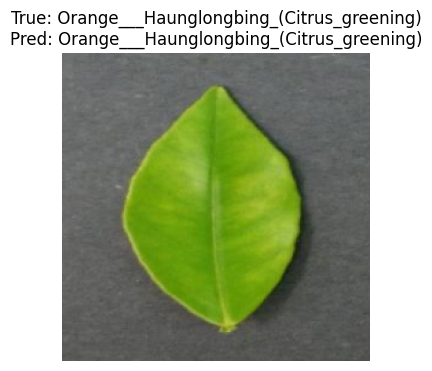

In [11]:
model.eval()
idx = random.randint(0, len(test_set) - 1)
image, label = test_set[idx]

with torch.no_grad():
    output = model(image.unsqueeze(0).to(device))
    pred = torch.argmax(output, dim=1).item()

true_name = class_names[label]
pred_name = class_names[pred]
print(f"预测结果: {pred_name} | 真实标签: {true_name}")
print("说明: 图中标题展示真实标签与预测标签, 供直观对比。")

# 反归一化用于显示
inv_norm = transforms.Normalize(
    mean=[-0.485 / 0.229, -0.456 / 0.224, -0.406 / 0.225],
    std=[1 / 0.229, 1 / 0.224, 1 / 0.225],
)
img_show = inv_norm(image).permute(1, 2, 0).cpu().numpy()
img_show = np.clip(img_show, 0, 1)

plt.figure(figsize=(4, 4))
plt.imshow(img_show)
plt.axis("off")
plt.title(f"True: {class_names[label]}\nPred: {class_names[pred]}")
plt.show()

## 10. 拓展与思考（含解题思路）

1. **问题**：如果想提升模型精度，除了增加 epoch，还可以尝试哪些方法？  
   **思路**：数据增强（更丰富的变换）、更合适的学习率策略（如 Cosine Annealing）、更强的模型（MobileNetV3、EfficientNet），以及类别不平衡处理（加权损失或重采样）。

2. **问题**：如何判断模型是否过拟合？  
   **思路**：若训练集准确率持续上升而验证集准确率停滞或下降，即可能过拟合。可以用早停、正则化或减少模型复杂度。

3. **问题**：如果要部署到移动端，你会关注哪些指标？  
   **思路**：模型大小、推理速度、内存占用。可使用量化、剪枝或更轻量的网络结构。

4. **问题**：为什么这里使用预训练权重？  
   **思路**：迁移学习能利用大规模数据集上学到的通用特征，减少训练时间并提升小样本任务的表现。

5. **问题**：如何把本模型用于“新病害类别”？  
   **思路**：收集新类别数据并扩充训练集，重置最后一层，进行微调或重新训练。